# Classical Baseline Models

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

In [2]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Toys_and_Games",
]

CATEGORY_LABELS = [
    "Electronics", "Books", "Clothing", "Home & Kitchen", "Toys"
]

FILE_STEMS = {
    "Electronics":                "electronics",
    "Books":                      "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Toys_and_Games":             "toys",
}

TFIDF_MAX_FEATURES = 50_000
TFIDF_NGRAM_RANGE  = (1, 2)
RANDOM_SEED        = 104
DRIVE_BASE         = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [3]:
import os
from google.colab import drive

drive.mount("/content/drive")
DATA_DIR    = f"{DRIVE_BASE}/data"
MODELS_DIR  = f"{DRIVE_BASE}/models"
RESULTS_DIR = f"{DRIVE_BASE}/results"
FIGURES_DIR = f"{DRIVE_BASE}/figures"

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

Mounted at /content/drive


In [4]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [5]:
def load_split(stem: str, split: str) -> pd.DataFrame:
    path = f"{DATA_DIR}/{stem}_{split}.csv"
    df = pd.read_csv(path)
    df["text"] = df["text"].fillna("").str.lower().str.strip()
    return df

train_data = {cat: load_split(FILE_STEMS[cat], "train") for cat in CATEGORIES}
test_data  = {cat: load_split(FILE_STEMS[cat], "test")  for cat in CATEGORIES}

val_data  = {cat: load_split(FILE_STEMS[cat], "val")  for cat in CATEGORIES}

print("Loaded all splits.")
for cat in CATEGORIES:
    print(f"  {cat}: train={len(train_data[cat])}, test={len(test_data[cat])}")

Loaded all splits.
  Electronics: train=3500, test=750
  Books: train=3500, test=750
  Clothing_Shoes_and_Jewelry: train=3500, test=750
  Home_and_Kitchen: train=3500, test=750
  Toys_and_Games: train=3500, test=750


In [ ]:
# Hyperparameter search on Electronics val set (reference category)
from sklearn.metrics import f1_score as _f1

_ref_stem = FILE_STEMS["Electronics"]
_vec_gs = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES, ngram_range=TFIDF_NGRAM_RANGE, sublinear_tf=True
)
_X_tr = _vec_gs.fit_transform(train_data["Electronics"]["text"])
_y_tr = train_data["Electronics"]["label"].values
_X_va = _vec_gs.transform(val_data["Electronics"]["text"])
_y_va = val_data["Electronics"]["label"].values

print("LogReg C search:")
_best_c, _best_f1 = 1.0, 0.0
for _C in [0.01, 0.1, 1.0, 10.0]:
    _clf = LogisticRegression(max_iter=1000, C=_C, solver="lbfgs",
                              random_state=RANDOM_SEED, n_jobs=-1)
    _clf.fit(_X_tr, _y_tr)
    _f = _f1(_y_va, _clf.predict(_X_va), average="macro")
    print(f"  C={_C:>6}  val_f1={_f:.4f}")
    if _f > _best_f1:
        _best_f1, _best_c = _f, _C
BEST_LOGREG_C = _best_c
print(f"  => Best C = {BEST_LOGREG_C}  (val_f1={_best_f1:.4f})")

print()
print("SVM alpha search:")
_best_alpha, _best_f1 = 1e-4, 0.0
for _alpha in [1e-4, 1e-3, 1e-2]:
    _clf = SGDClassifier(loss="hinge", alpha=_alpha, max_iter=1000, tol=1e-3,
                         random_state=RANDOM_SEED, n_jobs=-1)
    _clf.fit(_X_tr, _y_tr)
    _f = _f1(_y_va, _clf.predict(_X_va), average="macro")
    print(f"  alpha={_alpha:.0e}  val_f1={_f:.4f}")
    if _f > _best_f1:
        _best_f1, _best_alpha = _f, _alpha
BEST_SVM_ALPHA = _best_alpha
print(f"  => Best alpha = {BEST_SVM_ALPHA}  (val_f1={_best_f1:.4f})")

print()
print("Naive Bayes alpha search:")
_best_nb_alpha, _best_f1 = 1.0, 0.0
for _a in [0.01, 0.1, 1.0]:
    _clf = MultinomialNB(alpha=_a)
    _clf.fit(_X_tr, _y_tr)
    _f = _f1(_y_va, _clf.predict(_X_va), average="macro")
    print(f"  alpha={_a:.2f}  val_f1={_f:.4f}")
    if _f > _best_f1:
        _best_f1, _best_nb_alpha = _f, _a
BEST_NB_ALPHA = _best_nb_alpha
print(f"  => Best NB alpha = {BEST_NB_ALPHA}  (val_f1={_best_f1:.4f})")

print()
print("Random Forest grid search (n_estimators x max_depth):")
_best_rf_n, _best_rf_depth, _best_f1 = 100, None, 0.0
for _n in [50, 100]:
    for _d in [None, 30]:
        _clf = RandomForestClassifier(n_estimators=_n, max_depth=_d,
                                      max_features="sqrt", n_jobs=-1, random_state=RANDOM_SEED)
        _clf.fit(_X_tr, _y_tr)
        _f = _f1(_y_va, _clf.predict(_X_va), average="macro")
        _d_str = str(_d) if _d else "None"
        print(f"  n={_n:>3}  max_depth={_d_str:<4}  val_f1={_f:.4f}")
        if _f > _best_f1:
            _best_f1, _best_rf_n, _best_rf_depth = _f, _n, _d
BEST_RF_N     = _best_rf_n
BEST_RF_DEPTH = _best_rf_depth
print(f"  => Best RF: n_estimators={BEST_RF_N}, max_depth={BEST_RF_DEPTH}  (val_f1={_best_f1:.4f})")


In [6]:
def make_logreg(seed: int) -> LogisticRegression:
    return LogisticRegression(max_iter=1000, C=BEST_LOGREG_C, solver="lbfgs",
                              random_state=seed, n_jobs=-1)

def make_nb() -> MultinomialNB:
    return MultinomialNB(alpha=BEST_NB_ALPHA)

def make_rf(seed: int) -> RandomForestClassifier:
    return RandomForestClassifier(n_estimators=BEST_RF_N, max_depth=BEST_RF_DEPTH,
                                   max_features="sqrt", n_jobs=-1, random_state=seed)

def make_svm(seed: int) -> SGDClassifier:
    return SGDClassifier(loss="hinge", alpha=BEST_SVM_ALPHA, max_iter=1000, tol=1e-3,
                         random_state=seed, n_jobs=-1)

def train_pipeline(source_cat: str, clf_name: str, seed: int):
    """Fit TF-IDF + classifier on source_cat train set. Return (vectoriser, clf)."""
    df_train = train_data[source_cat]
    vec = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=TFIDF_NGRAM_RANGE,
        sublinear_tf=True,
    )
    X = vec.fit_transform(df_train["text"])
    y = df_train["label"].values

    if   clf_name == "logreg": clf = make_logreg(seed)
    elif clf_name == "svm":    clf = make_svm(seed)
    elif clf_name == "nb":     clf = make_nb()
    else:                      clf = make_rf(seed)
    clf.fit(X, y)

    stem     = FILE_STEMS[source_cat]
    model_dir = f"{MODELS_DIR}/{clf_name}_{stem}"
    os.makedirs(model_dir, exist_ok=True)
    joblib.dump(vec, f"{model_dir}/tfidf_vectoriser.joblib")
    joblib.dump(clf, f"{model_dir}/{clf_name}_classifier.joblib")

    return vec, clf


def evaluate_transfer(vec, clf, target_cat: str) -> dict:
    df_test = test_data[target_cat]
    X_test  = vec.transform(df_test["text"])
    y_true  = df_test["label"].values
    y_pred  = clf.predict(X_test)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1":       f1_score(y_true, y_pred, average="macro"),
        "y_true":   y_true,
        "y_pred":   y_pred,
    }

In [7]:
results: dict[str, dict] = {"logreg": {}, "svm": {}, "nb": {}, "rf": {}}

for clf_name in ["logreg", "svm", "nb", "rf"]:
    print(f"Model: {clf_name.upper()}")
    for source_cat in CATEGORIES:
        print()
        print(f"Training on {source_cat} …")
        vec, clf = train_pipeline(source_cat, clf_name, RANDOM_SEED)

        results[clf_name][source_cat] = {}
        for target_cat in CATEGORIES:
            res = evaluate_transfer(vec, clf, target_cat)
            results[clf_name][source_cat][target_cat] = res
            tag = "(in-domain)" if source_cat == target_cat else ""
            print(f"  {target_cat:<35} acc={res['accuracy']:.3f}  f1={res['f1']:.3f} {tag}")

        print(f"  In-domain classification report ({source_cat}):")
        r = results[clf_name][source_cat][source_cat]
        print(classification_report(r["y_true"], r["y_pred"],
                                    target_names=["negative", "positive"]))

Model: LOGREG

Training on Electronics …
  Electronics                         acc=0.904  f1=0.904 (in-domain)
  Books                               acc=0.821  f1=0.821 
  Clothing_Shoes_and_Jewelry          acc=0.847  f1=0.846 
  Home_and_Kitchen                    acc=0.895  f1=0.895 
  Toys_and_Games                      acc=0.873  f1=0.873 
  In-domain classification report (Electronics):
              precision    recall  f1-score   support

    negative       0.89      0.93      0.91       375
    positive       0.92      0.88      0.90       375

    accuracy                           0.90       750
   macro avg       0.90      0.90      0.90       750
weighted avg       0.90      0.90      0.90       750


Training on Books …
  Electronics                         acc=0.805  f1=0.803 
  Books                               acc=0.912  f1=0.912 (in-domain)
  Clothing_Shoes_and_Jewelry          acc=0.795  f1=0.792 
  Home_and_Kitchen                    acc=0.809  f1=0.808 
  Toys_an

In [8]:
def build_matrix(clf_name: str, metric: str = "accuracy") -> pd.DataFrame:
    mat = pd.DataFrame(
        index=CATEGORIES, columns=CATEGORIES, dtype=float
    )
    for src in CATEGORIES:
        for tgt in CATEGORIES:
            mat.loc[src, tgt] = results[clf_name][src][tgt][metric]
    mat.index   = CATEGORY_LABELS
    mat.columns = CATEGORY_LABELS
    return mat

logreg_acc = build_matrix("logreg", "accuracy")
svm_acc    = build_matrix("svm",    "accuracy")
logreg_f1  = build_matrix("logreg", "f1")
svm_f1     = build_matrix("svm",    "f1")

logreg_acc.to_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_logreg.csv")
svm_acc.to_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_svm.csv")

print("Transfer matrices saved.")
print("LogReg accuracy matrix:")
print(logreg_acc.to_string())
nb_acc = build_matrix("nb", "accuracy")
nb_f1  = build_matrix("nb", "f1")
rf_acc = build_matrix("rf", "accuracy")
rf_f1  = build_matrix("rf", "f1")

nb_acc.to_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_nb.csv")
nb_f1.to_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_nb_f1.csv")
rf_acc.to_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_rf.csv")
rf_f1.to_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_rf_f1.csv")
print("NB and RF matrices saved.")


Transfer matrices saved.
LogReg accuracy matrix:
                Electronics     Books  Clothing  Home & Kitchen      Toys
Electronics        0.904000  0.821333  0.846667        0.894667  0.873333
Books              0.805333  0.912000  0.794667        0.809333  0.850667
Clothing           0.853333  0.790667  0.890667        0.890667  0.857333
Home & Kitchen     0.840000  0.773333  0.872000        0.908000  0.841333
Toys               0.838667  0.816000  0.838667        0.861333  0.906667


## Visualisation: Transfer matrix heatmaps

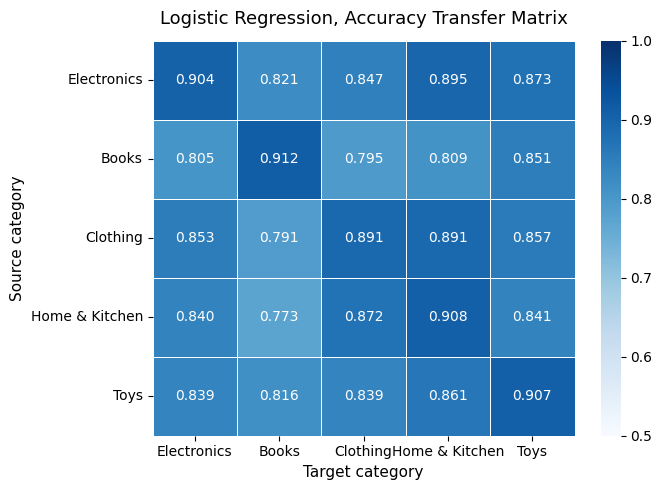

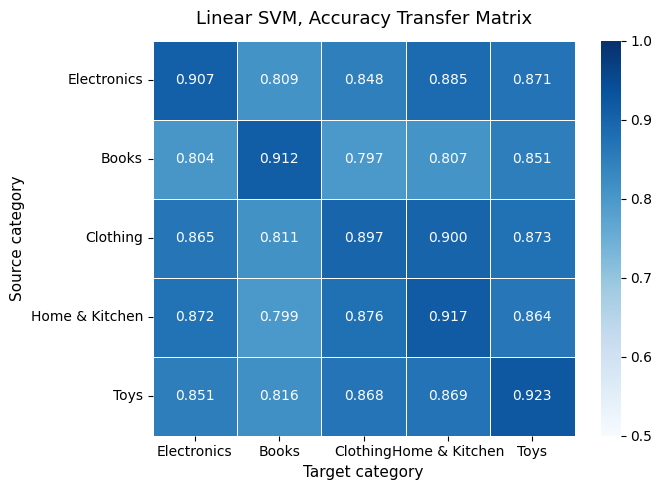

In [9]:
def plot_heatmap(mat: pd.DataFrame, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        mat.astype(float), annot=True, fmt=".3f",
        cmap="Blues", vmin=0.5, vmax=1.0,
        linewidths=0.5, ax=ax,
        xticklabels=mat.columns, yticklabels=mat.index,
    )
    ax.set_xlabel("Target category", fontsize=11)
    ax.set_ylabel("Source category", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", dpi=150)
    plt.show()

plot_heatmap(logreg_acc, "Logistic Regression, Accuracy Transfer Matrix", "heatmap_logreg.png")
plot_heatmap(svm_acc,    "Linear SVM, Accuracy Transfer Matrix",          "heatmap_svm.png")
plot_heatmap(nb_acc, "Naive Bayes: Accuracy Transfer Matrix",   "heatmap_nb.png")
plot_heatmap(rf_acc, "Random Forest: Accuracy Transfer Matrix", "heatmap_rf.png")


## Visualisation: In-domain vs average cross-domain accuracy

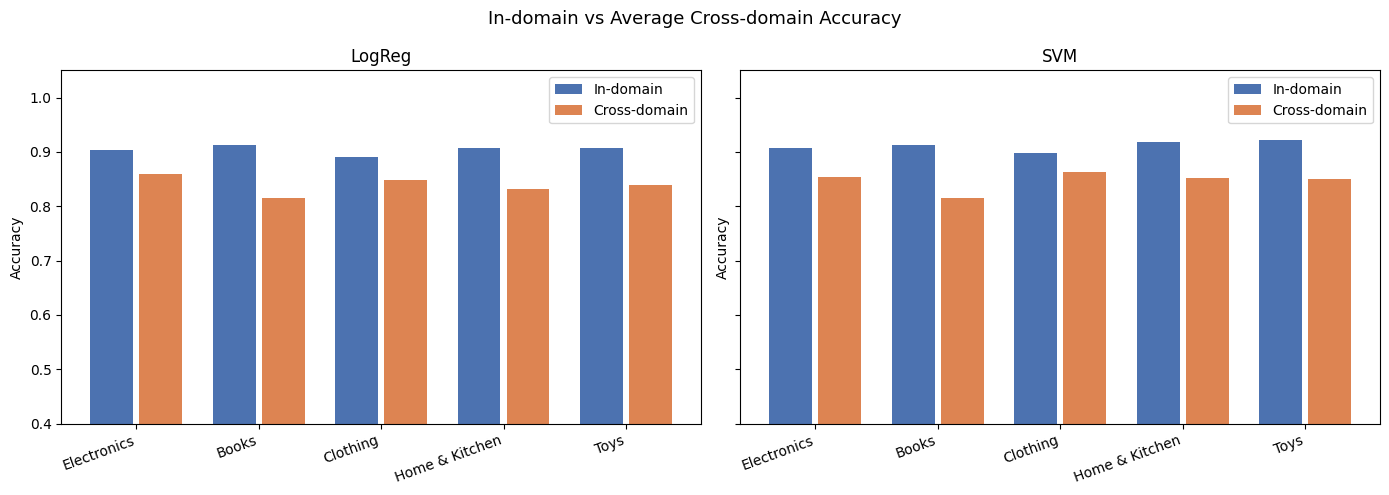

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for ax, (clf_name, mat) in zip(axes.flat, [("LogReg", logreg_acc), ("SVM", svm_acc), ("NB", nb_acc), ("RF", rf_acc)]):
    n = len(CATEGORY_LABELS)
    x = np.arange(n)
    in_domain    = [mat.iloc[i, i]                         for i in range(n)]
    cross_domain = [(mat.iloc[i].sum() - mat.iloc[i, i]) / (n - 1) for i in range(n)]

    ax.bar(x - 0.2, in_domain,    0.35, label="In-domain",    color="#4c72b0")
    ax.bar(x + 0.2, cross_domain, 0.35, label="Cross-domain", color="#dd8452")
    ax.set_xticks(x)
    ax.set_xticklabels(CATEGORY_LABELS, rotation=20, ha="right")
    ax.set_ylim(0.4, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title(clf_name)
    ax.legend()

fig.suptitle("In-domain vs Average Cross-domain Accuracy", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/accuracy_comparison_bar_baselines.png", dpi=150)
plt.show()

## Degradation summary

In [11]:
for clf_name, mat in [("LogReg", logreg_acc), ("SVM", svm_acc), ("NB", nb_acc), ("RF", rf_acc)]:
    print()
    print(clf_name)
    print(f"  Average in-domain accuracy:    {np.diag(mat.values.astype(float)).mean():.3f}")
    off = []
    for i in range(len(CATEGORY_LABELS)):
        for j in range(len(CATEGORY_LABELS)):
            if i != j:
                off.append(float(mat.iloc[i, j]))
    print(f"  Average cross-domain accuracy: {np.mean(off):.3f}")
    print(f"  Average degradation:           {np.diag(mat.values.astype(float)).mean() - np.mean(off):.3f}")


LogReg
  Average in-domain accuracy:    0.904
  Average cross-domain accuracy: 0.838
  Average degradation:           0.066

SVM
  Average in-domain accuracy:    0.911
  Average cross-domain accuracy: 0.847
  Average degradation:           0.064
